 # Classifiers KNN - SVM - MLP & CNN
 The goal of this extra is to do thae same as the previous but with the MNIST dataset and a Convolutional Neural Network (CNN) classifier.

### Importing Libraries

In [54]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
# for the classifiers
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score, log_loss
from sklearn.neighbors import KNeighborsClassifier as KNN # K-Nearest Neighbors
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier as MLP # Multi-layer Perceptron

## MNIST dataset
Looking at the MNIST dataset by printing first 10 images with their labels, the number of samples for each label and its shape.

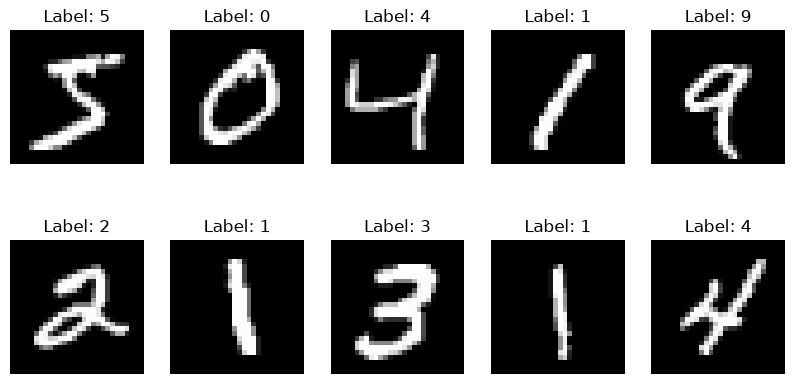

0:6903   1:7877   2:6990   3:7141   4:6824   5:6313   6:6876   7:7293   8:6825   9:6958  
X shape: (70000, 784) | y shape: (70000,)


In [55]:
mnist = fetch_openml("mnist_784", as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.axis('off')
    plt.imshow(X[i].reshape(28, 28), cmap='grey')
    plt.title(f"Label: {y[i]}")
plt.show()

print(*(f"{i}:{np.bincount(y)[i]}  " for i in range(10)))
print(f"X shape: {X.shape} | y shape: {y.shape}")

#### KNN - SVM - MLP
The next code cell will be used to train and test the KNN, SVM and MLP classifiers with the MNIST dataset. It will not use GridSearch, since the goal is just to show slow performance of these classifiers with a large dataset. The data will be scaled.

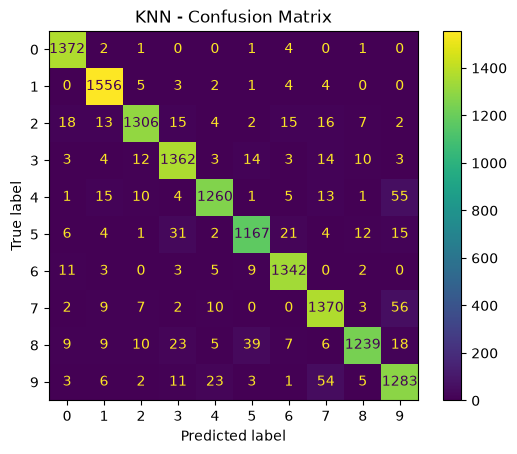

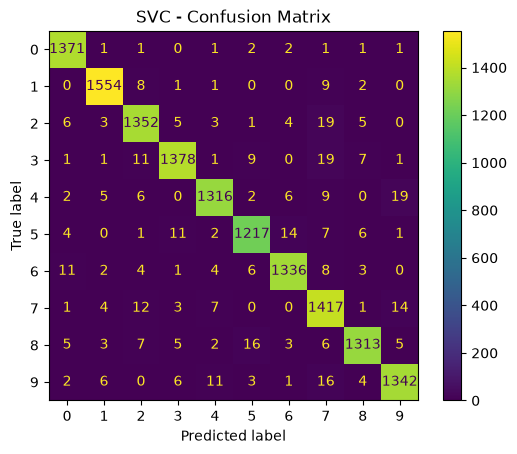

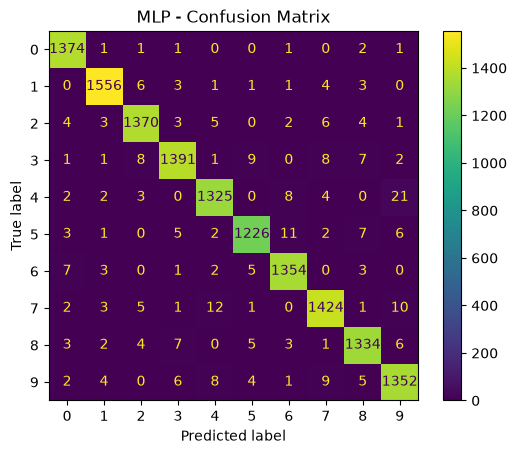

In [56]:
data_clf = list()
y_pred_clf = dict()

classifiers = {"KNN": KNN(n_neighbors=3, weights="distance"), 
               "SVC": SVC(C=10, gamma=0.001, kernel="rbf"),
               "MLP": MLP(hidden_layer_sizes=(128, 64), alpha=0.1, learning_rate_init= 0.0001, max_iter=1000, random_state=42)}

for name, clf in classifiers.items():
    pipe = make_pipeline(StandardScaler(), clf)

    t0 = time.perf_counter()
    pipe.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    y_pred = pipe.predict(X_te)
    pred_time = time.perf_counter() - t0

    y_pred_clf[name] = y_pred

    data_clf.append({"Classifier": name,
                     "Accuracy": accuracy_score(y_te, y_pred),
                     "F1": f1_score(y_te, y_pred, average="macro"),
                     "Training Time (s)": train_time,
                     "Prediction Time per sample (ms)": pred_time / len(X_te) * 1000})

    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

#### Results Tables for KNN, SVM and MLP

In [57]:
df = pd.DataFrame(data_clf).set_index("Classifier").round(4)
df

,Accuracy,F1,Training Time (s),Prediction Time per sample (ms)
Classifier,,,,
KNN,0.9469,0.9464,1.2708,0.4012
SVC,0.9711,0.9710,260.2332,8.8709
MLP,0.9790,0.9789,282.8911,0.0134


### Training/Cross-validation Loss & Accuracy Curve for MLP Classifier
This code will generate a plot with the training and cross-validation loss and accuracy curves for the MLP classifier, in order to visualize if the epoch number is correct.

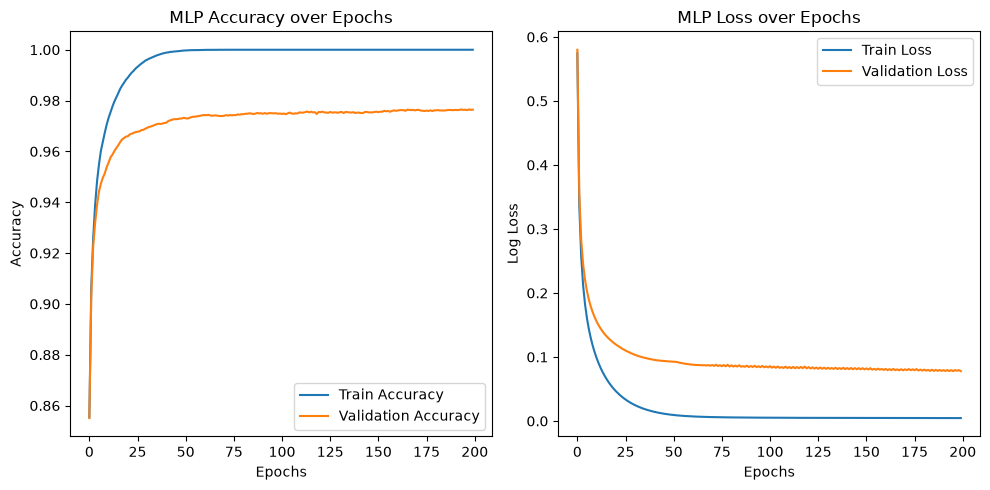

In [58]:
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

scaler = StandardScaler().fit(X_fit)
X_fit_s, X_val_s = scaler.transform(X_fit), scaler.transform(X_val)

mlp = MLP(hidden_layer_sizes=(128, 64), alpha=0.1, learning_rate_init= 0.0001, random_state=42)
train_acc, val_acc = list(), list()
train_loss, val_loss = list(), list()

for epoch in range(200):
    mlp.partial_fit(X_fit_s, y_fit, classes=np.unique(y_tr))
    
    train_acc.append(mlp.score(X_fit_s, y_fit))
    val_acc.append(mlp.score(X_val_s, y_val))

    train_loss.append(log_loss(y_fit, mlp.predict_proba(X_fit_s)))
    val_loss.append(log_loss(y_val, mlp.predict_proba(X_val_s)))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("MLP Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("MLP Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Misclassified Images for KNN, SVM and MLP Classifiers





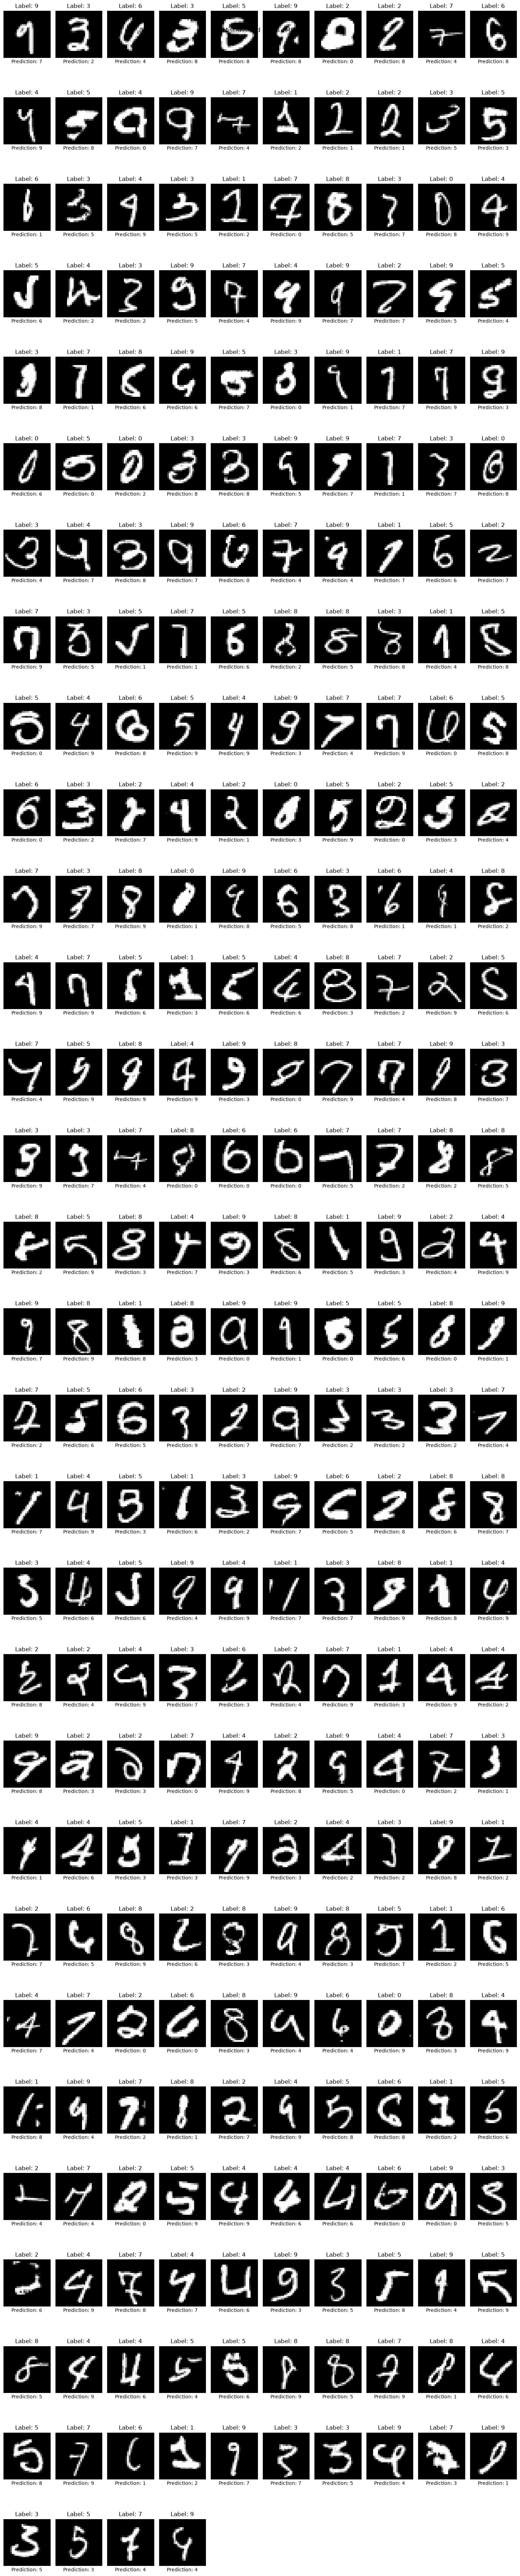

In [59]:
for name, y_pred in y_pred_clf.items():
    wrong = np.where(y_pred != y_te)[0]
    n_cols = min(10, len(wrong))
    n_rows = int(np.ceil(len(wrong) / n_cols))

    plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
    plt.suptitle(f"Misclassified Digits - {name}")

    for k, i in enumerate(wrong):
        plt.subplot(n_rows, n_cols, k + 1)
        plt.imshow(X_te[i].reshape(28, 28), cmap="gray")
        plt.title(f"Label: {y_te[i]}")
        plt.xlabel(f"Prediction: {y_pred[i]}")
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()


### CNN
> Not even going to bother testing without scaling, since CNN is a neural network and it will defenitely benefit from scaling.

In [60]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(nn.Conv2d(1, 32, (3, 3), padding=1),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(32, 64, (3,3), padding=1),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Flatten(),
                                        nn.Dropout(),
                                        nn.Linear(64 * 7 * 7, 128),
                                        nn.ReLU(),
                                        nn.Dropout(),
                                        nn.Linear(128, 10))

    def forward(self, x):
        return self.classifier(x)

In [61]:
def to_loader(X, y, batch, shuf):
    X_t = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28)
    y_t = torch.tensor(y, dtype=torch.long)

    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch, shuffle=shuf)

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

mean, std = X_fit.mean(), X_fit.std()
X_fit_s, X_val_s, X_te_s = (X_fit - mean) / std, (X_val - mean) / std, (X_te - mean) / std

fit_loader = to_loader(X_fit_s, y_fit, 128, True)
val_loader = to_loader(X_val_s, y_val, 1024, False)
test_loader = to_loader(X_te_s, y_te, 1024, False)

In [63]:
train_acc_cnn, val_acc_cnn = list(), list()
train_loss_cnn, val_loss_cnn = list(), list()

epochs = 20
torch.manual_seed(42)
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

t0 = time.perf_counter()

for epoch in range(epochs):
    model.train()
    total_loss, correct = 0.0, 0

    for xb, yb in fit_loader:

        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()

    train_loss_cnn.append(total_loss / len(fit_loader.dataset))
    train_acc_cnn.append(correct / len(fit_loader.dataset))

    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for xb, yb in val_loader:

            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()

    val_loss_cnn.append(total_loss / len(val_loader.dataset))
    val_acc_cnn.append(correct / len(val_loader.dataset))

    if ((epoch + 1) % 5 == 0): print(f"epoch: {epoch + 1}")

train_time = time.perf_counter() - t0

epoch: 5
epoch: 10
epoch: 15
epoch: 20


#### Training/Cross-validation Loss & Accuracy Curve for the CNN

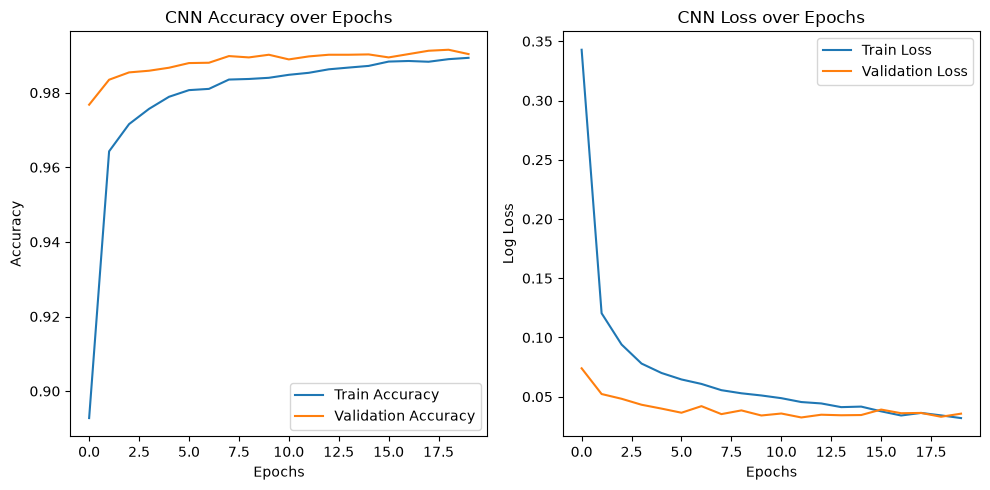

In [64]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_cnn, label="Train Accuracy")
plt.plot(val_acc_cnn, label="Validation Accuracy")
plt.title("CNN Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss_cnn, label="Train Loss")
plt.plot(val_loss_cnn, label="Validation Loss")
plt.title("CNN Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

> #### Conclusions about the graphs
> In the early epochs, validation accuracy is higher than training accuracy and the same with loss but in the opposite direction. Thats because:
>- Training metrics are measured while Dropout is switched on, and averaged over the whole epoch, including the start when the model was still worse.
>- Validation is measured at the end of the epoch, with Dropout off.
>
> The Accuracy and Loss curves are as expected, converging around 20 epochs (checked the graph with 100 epochs and 20 is enough) and not overfitting.

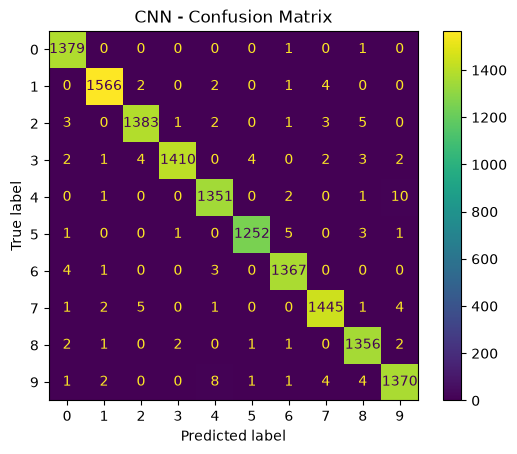

In [65]:
model.eval()
preds = list()

t0 = time.perf_counter()
with torch.no_grad():
    for xb, _ in test_loader:
        out = model(xb.to(device))
        preds.append(out.argmax(1).cpu().numpy())

pred_time = time.perf_counter() - t0

y_pred = np.concatenate(preds)
y_pred_clf["CNN"] = y_pred

data_clf = [d for d in data_clf if d["Classifier"] != "CNN"]
data_clf.append({"Classifier": "CNN",
                 "Accuracy": accuracy_score(y_te, y_pred),
                 "F1": f1_score(y_te, y_pred, average="macro"),
                 "Training Time (s)": train_time,
                 "Prediction Time per sample (ms)": pred_time / len(X_te) * 1000})

ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("CNN - Confusion Matrix")
plt.show()

In [66]:
pd.DataFrame(data_clf).set_index("Classifier").round(4)

,Accuracy,F1,Training Time (s),Prediction Time per sample (ms)
Classifier,,,,
KNN,0.9469,0.9464,1.2708,0.4012
SVC,0.9711,0.9710,260.2332,8.8709
MLP,0.9790,0.9789,282.8911,0.0134
CNN,0.9914,0.9913,37.1659,0.0143


### Misclassified Images for the CNN

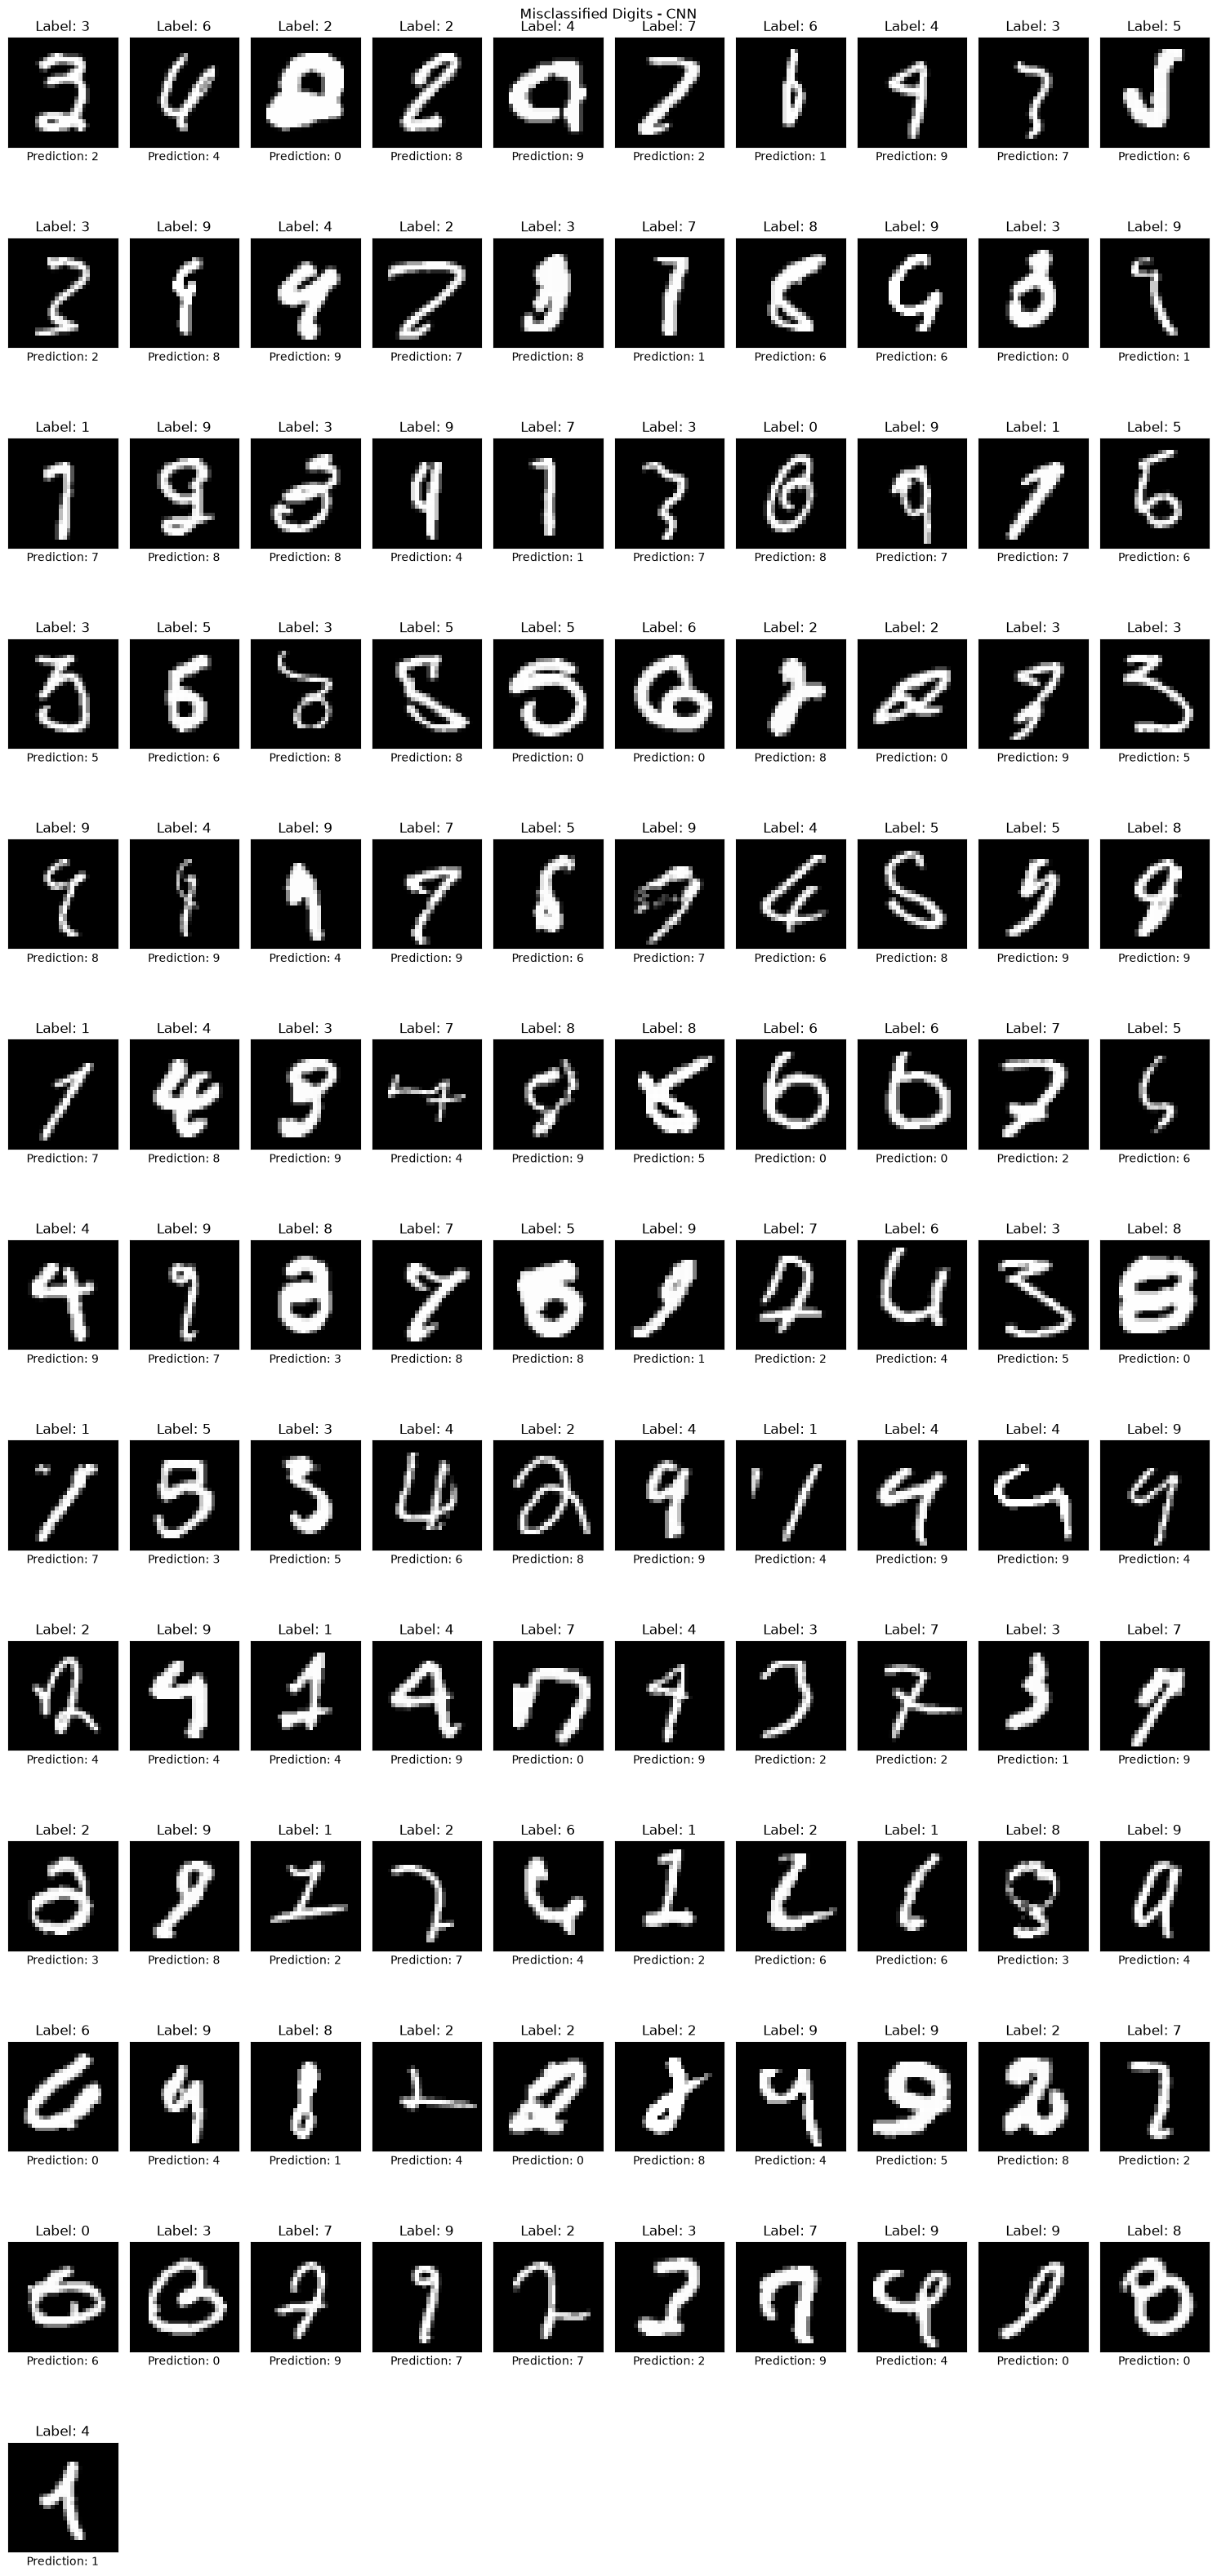

In [67]:
wrong = np.where(y_pred_clf["CNN"] != y_te)[0]
n_cols = min(10, len(wrong))
n_rows = int(np.ceil(len(wrong) / n_cols))

plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
plt.suptitle("Misclassified Digits - CNN")

for k, i in enumerate(wrong):
    plt.subplot(n_rows, n_cols, k + 1)
    plt.imshow(X_te[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_te[i]}")
    plt.xlabel(f"Prediction: {y_pred_clf["CNN"][i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()